# 🛒 Olist Brazilian E-Commerce — Exploratory Data Analysis

**Dataset:** [Olist E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Period:** September 2016 – October 2018  
**Tables:** 9 CSVs covering orders, customers, sellers, products, payments, reviews, geolocation

---
### Sections
1. [Setup & Data Loading](#1-setup)
2. [Dataset Overview](#2-overview)
3. [Order Analysis](#3-orders)
4. [Revenue & Payments](#4-revenue)
5. [Delivery Performance](#5-delivery)
6. [Customer Reviews](#6-reviews)
7. [Product & Category Analysis](#7-products)
8. [Geographic Analysis](#8-geography)
9. [Customer Behaviour](#9-customers)
10. [Seller Analysis](#10-sellers)
11. [Key Insights Summary](#11-insights)

## 1. Setup & Data Loading <a id='1-setup'></a>

In [1]:
# Install dependencies if needed
# !pip install pandas numpy matplotlib seaborn plotly folium

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE = ['#378ADD', '#1D9E75', '#D85A30', '#534AB7', '#BA7517', '#D4537E', '#888780']
sns.set_palette(PALETTE)
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
DATA = 'data/'   # adjust path if needed

orders      = pd.read_csv(f'{DATA}olist_orders_dataset.csv', parse_dates=[
                  'order_purchase_timestamp','order_approved_at',
                  'order_delivered_carrier_date','order_delivered_customer_date',
                  'order_estimated_delivery_date'])
customers   = pd.read_csv(f'{DATA}olist_customers_dataset.csv')
order_items = pd.read_csv(f'{DATA}olist_order_items_dataset.csv',
                  parse_dates=['shipping_limit_date'])
payments    = pd.read_csv(f'{DATA}olist_order_payments_dataset.csv')
reviews     = pd.read_csv(f'{DATA}olist_order_reviews_dataset.csv',
                  parse_dates=['review_creation_date','review_answer_timestamp'])
products    = pd.read_csv(f'{DATA}olist_products_dataset.csv')
sellers     = pd.read_csv(f'{DATA}olist_sellers_dataset.csv')
geolocation = pd.read_csv(f'{DATA}olist_geolocation_dataset.csv')
cat_trans   = pd.read_csv(f'{DATA}product_category_name_translation.csv')

print('All datasets loaded ✓')
for name, df in [('orders',orders),('customers',customers),('order_items',order_items),
                 ('payments',payments),('reviews',reviews),('products',products),
                 ('sellers',sellers),('geolocation',geolocation),('cat_trans',cat_trans)]:
    print(f'  {name:<20} {df.shape[0]:>8,} rows  {df.shape[1]:>3} cols')

All datasets loaded ✓
  orders                 99,441 rows    8 cols
  customers              99,441 rows    5 cols
  order_items           112,650 rows    7 cols
  payments              103,886 rows    5 cols
  reviews                99,224 rows    7 cols
  products               32,951 rows    9 cols
  sellers                 3,095 rows    4 cols
  geolocation          1,000,163 rows    5 cols
  cat_trans                  71 rows    2 cols


## 2. Dataset Overview <a id='2-overview'></a>

In [3]:
# Schema overview — null counts & dtypes
for name, df in [('orders', orders), ('order_items', order_items),
                 ('payments', payments), ('reviews', reviews)]:
    print(f'\n=== {name} ===')
    info = pd.DataFrame({'dtype': df.dtypes, 'nulls': df.isnull().sum(),
                          'null_%': (df.isnull().mean()*100).round(1)})
    print(info.to_string())


=== orders ===
                                        dtype  nulls  null_%
order_id                               object      0     0.0
customer_id                            object      0     0.0
order_status                           object      0     0.0
order_purchase_timestamp       datetime64[ns]      0     0.0
order_approved_at              datetime64[ns]    160     0.2
order_delivered_carrier_date   datetime64[ns]   1783     1.8
order_delivered_customer_date  datetime64[ns]   2965     3.0
order_estimated_delivery_date  datetime64[ns]      0     0.0

=== order_items ===
                              dtype  nulls  null_%
order_id                     object      0     0.0
order_item_id                 int64      0     0.0
product_id                   object      0     0.0
seller_id                    object      0     0.0
shipping_limit_date  datetime64[ns]      0     0.0
price                       float64      0     0.0
freight_value               float64      0     0.0

=== p

In [4]:
# Key summary metrics
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['days_to_deliver'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_purchase_timestamp']).dt.days

total_revenue = order_items['price'].sum() + order_items['freight_value'].sum()
avg_order     = payments.groupby('order_id')['payment_value'].sum().mean()

metrics = {
    'Total orders':       f"{len(orders):,}",
    'Delivered orders':   f"{len(delivered):,}  ({len(delivered)/len(orders)*100:.1f}%)",
    'Total revenue':      f"R$ {total_revenue:,.0f}",
    'Avg order value':    f"R$ {avg_order:.2f}",
    'Unique customers':   f"{orders['customer_id'].nunique():,}",
    'Unique sellers':     f"{order_items['seller_id'].nunique():,}",
    'Unique products':    f"{order_items['product_id'].nunique():,}",
    'Avg delivery days':  f"{delivered['days_to_deliver'].mean():.1f}",
    'Median delivery':    f"{delivered['days_to_deliver'].median():.0f} days",
    'Date range':         f"{orders['order_purchase_timestamp'].min().date()} → {orders['order_purchase_timestamp'].max().date()}",
}
for k, v in metrics.items():
    print(f'{k:<25} {v}')

Total orders              99,441
Delivered orders          96,478  (97.0%)
Total revenue             R$ 15,843,553
Avg order value           R$ 160.99
Unique customers          99,441
Unique sellers            3,095
Unique products           32,951
Avg delivery days         12.1
Median delivery           10 days
Date range                2016-09-04 → 2018-10-17


## 3. Order Analysis <a id='3-orders'></a>

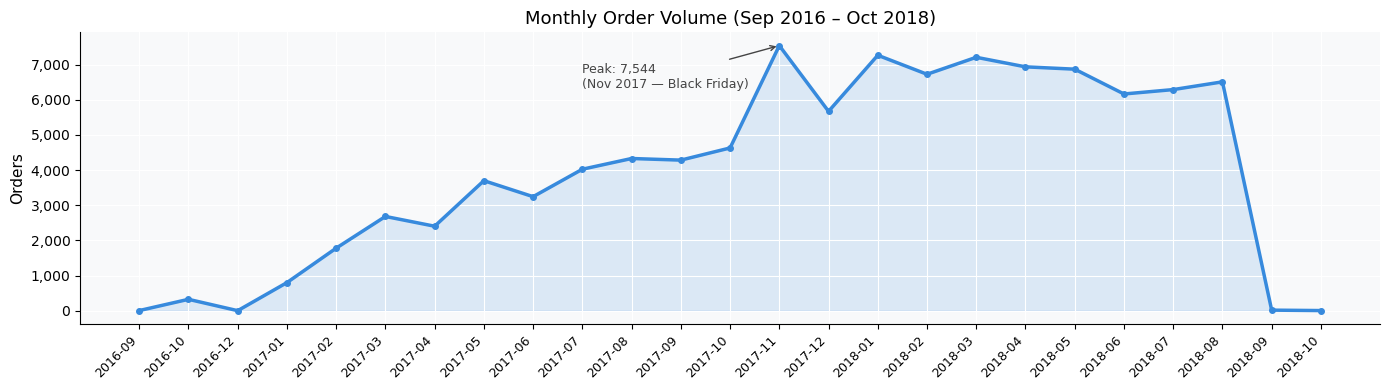

In [5]:
# Monthly order volume
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('month').size().reset_index(name='orders')
monthly['month_str'] = monthly['month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(len(monthly)), monthly['orders'],
                alpha=0.15, color='#378ADD')
ax.plot(range(len(monthly)), monthly['orders'],
        color='#378ADD', linewidth=2.5, marker='o', markersize=4)

# Annotate peak
peak_idx = monthly['orders'].idxmax()
ax.annotate(f"Peak: {monthly.loc[peak_idx,'orders']:,}\n(Nov 2017 — Black Friday)",
            xy=(peak_idx, monthly.loc[peak_idx,'orders']),
            xytext=(peak_idx - 4, monthly.loc[peak_idx,'orders'] - 1200),
            arrowprops=dict(arrowstyle='->', color='#444'),
            fontsize=9, color='#444')

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_title('Monthly Order Volume (Sep 2016 – Oct 2018)', fontsize=13)
ax.set_ylabel('Orders')
plt.tight_layout()
plt.show()

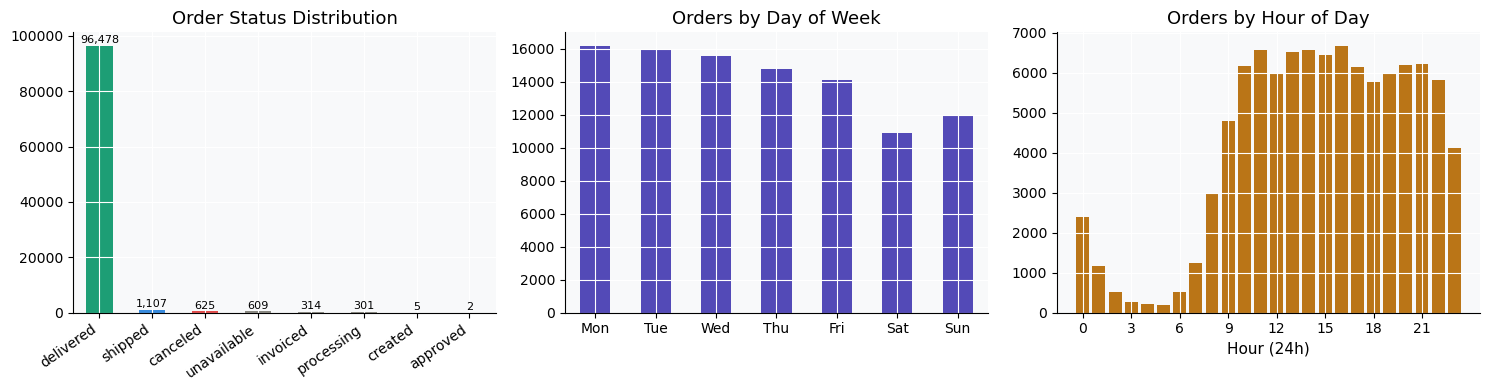

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Order status
status_counts = orders['order_status'].value_counts()
colors_status = ['#1D9E75' if s == 'delivered' else '#E24B4A' if s == 'canceled'
                 else '#378ADD' if s == 'shipped' else '#888780'
                 for s in status_counts.index]
status_counts.plot(kind='bar', ax=axes[0], color=colors_status, edgecolor='none')
axes[0].set_title('Order Status Distribution')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

# Day of week
orders['dow'] = orders['order_purchase_timestamp'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = orders['dow'].value_counts().reindex(dow_order)
dow_counts.plot(kind='bar', ax=axes[1], color='#534AB7', edgecolor='none')
axes[1].set_title('Orders by Day of Week')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)

# Hour of day
orders['hour'] = orders['order_purchase_timestamp'].dt.hour
hour_counts = orders.groupby('hour').size()
axes[2].bar(hour_counts.index, hour_counts.values, color='#BA7517', edgecolor='none')
axes[2].set_title('Orders by Hour of Day')
axes[2].set_xlabel('Hour (24h)')
axes[2].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

## 4. Revenue & Payments <a id='4-revenue'></a>

In [7]:
# Payment type breakdown
pay_type = payments.groupby('payment_type').agg(
    count=('order_id','nunique'),
    total_value=('payment_value','sum')
).sort_values('count', ascending=False)
pay_type['pct_orders'] = (pay_type['count'] / pay_type['count'].sum() * 100).round(1)
pay_type['pct_value']  = (pay_type['total_value'] / pay_type['total_value'].sum() * 100).round(1)
print(pay_type.to_string())

              count  total_value  pct_orders  pct_value
payment_type                                           
credit_card   76505  12542084.19        75.2       78.3
boleto        19784   2869361.27        19.5       17.9
voucher        3866    379436.87         3.8        2.4
debit_card     1528    217989.79         1.5        1.4
not_defined       3         0.00         0.0        0.0


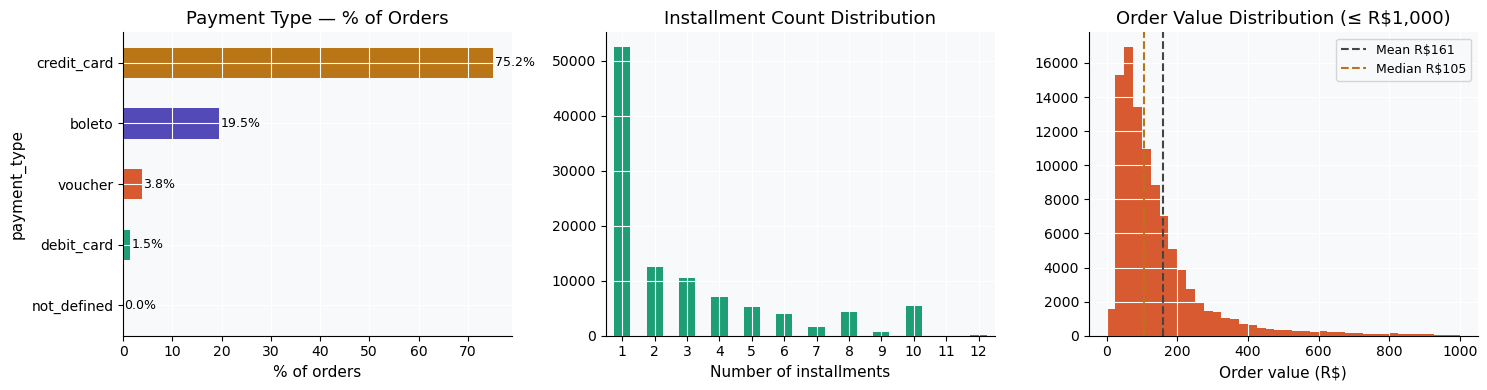

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Payment type — order share
pay_type['pct_orders'].sort_values().plot(
    kind='barh', ax=axes[0], color=PALETTE[:len(pay_type)], edgecolor='none')
axes[0].set_title('Payment Type — % of Orders')
axes[0].set_xlabel('% of orders')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}%', va='center', fontsize=9)

# Installments distribution
install = payments[payments['payment_installments'] > 0]['payment_installments'].value_counts().sort_index()
install = install[install.index <= 12]
install.plot(kind='bar', ax=axes[1], color='#1D9E75', edgecolor='none')
axes[1].set_title('Installment Count Distribution')
axes[1].set_xlabel('Number of installments')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Order value histogram
order_vals = payments.groupby('order_id')['payment_value'].sum()
order_vals_clipped = order_vals[order_vals <= 1000]
axes[2].hist(order_vals_clipped, bins=40, color='#D85A30', edgecolor='none')
axes[2].axvline(order_vals.mean(), color='#444', linestyle='--', linewidth=1.5,
                label=f'Mean R${order_vals.mean():.0f}')
axes[2].axvline(order_vals.median(), color='#BA7517', linestyle='--', linewidth=1.5,
                label=f'Median R${order_vals.median():.0f}')
axes[2].set_title('Order Value Distribution (≤ R$1,000)')
axes[2].set_xlabel('Order value (R$)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

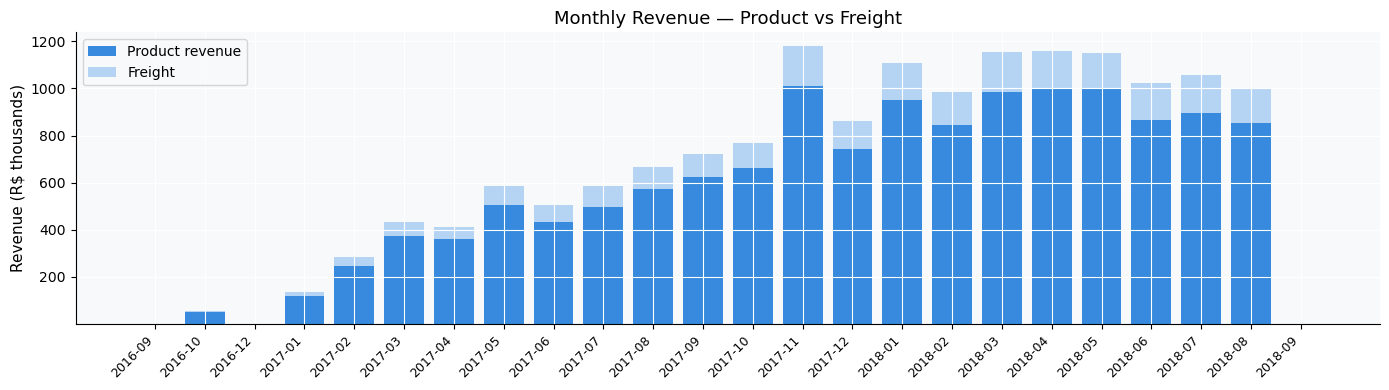

In [9]:
# Monthly revenue trend
order_items_with_date = order_items.merge(
    orders[['order_id','order_purchase_timestamp']], on='order_id')
order_items_with_date['month'] = order_items_with_date['order_purchase_timestamp'].dt.to_period('M')
monthly_rev = order_items_with_date.groupby('month').agg(
    revenue=('price','sum'), freight=('freight_value','sum')).reset_index()
monthly_rev['total'] = monthly_rev['revenue'] + monthly_rev['freight']
monthly_rev['month_str'] = monthly_rev['month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
x = range(len(monthly_rev))
ax.bar(x, monthly_rev['revenue']/1000, label='Product revenue', color='#378ADD', edgecolor='none')
ax.bar(x, monthly_rev['freight']/1000, bottom=monthly_rev['revenue']/1000,
       label='Freight', color='#B5D4F4', edgecolor='none')
ax.set_xticks(list(x))
ax.set_xticklabels(monthly_rev['month_str'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Revenue (R$ thousands)')
ax.set_title('Monthly Revenue — Product vs Freight')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Delivery Performance <a id='5-delivery'></a>

In [10]:
# Build delivery metrics for delivered orders
deliv = delivered.copy()
deliv['days_to_approve']  = (deliv['order_approved_at'] - deliv['order_purchase_timestamp']).dt.days
deliv['days_to_carrier']  = (deliv['order_delivered_carrier_date'] - deliv['order_approved_at']).dt.days
deliv['days_in_transit']  = (deliv['order_delivered_customer_date'] - deliv['order_delivered_carrier_date']).dt.days
deliv['on_time'] = deliv['order_delivered_customer_date'] <= deliv['order_estimated_delivery_date']
deliv['delta_days'] = (deliv['order_estimated_delivery_date'] - deliv['order_delivered_customer_date']).dt.days

print(f"On-time delivery rate: {deliv['on_time'].mean()*100:.1f}%")
print(f"\nDelivery time summary (days):")
print(deliv[['days_to_approve','days_to_carrier','days_in_transit','days_to_deliver']].describe().round(1).to_string())

On-time delivery rate: 91.9%

Delivery time summary (days):
       days_to_approve  days_to_carrier  days_in_transit  days_to_deliver
count          96464.0          96462.0          96469.0          96470.0
mean               0.3              2.3              8.9             12.1
std                0.7              3.5              8.7              9.6
min                0.0           -172.0            -17.0              0.0
25%                0.0              0.0              4.0              6.0
50%                0.0              1.0              7.0             10.0
75%                0.0              3.0             12.0             15.0
max               30.0            125.0            205.0            209.0


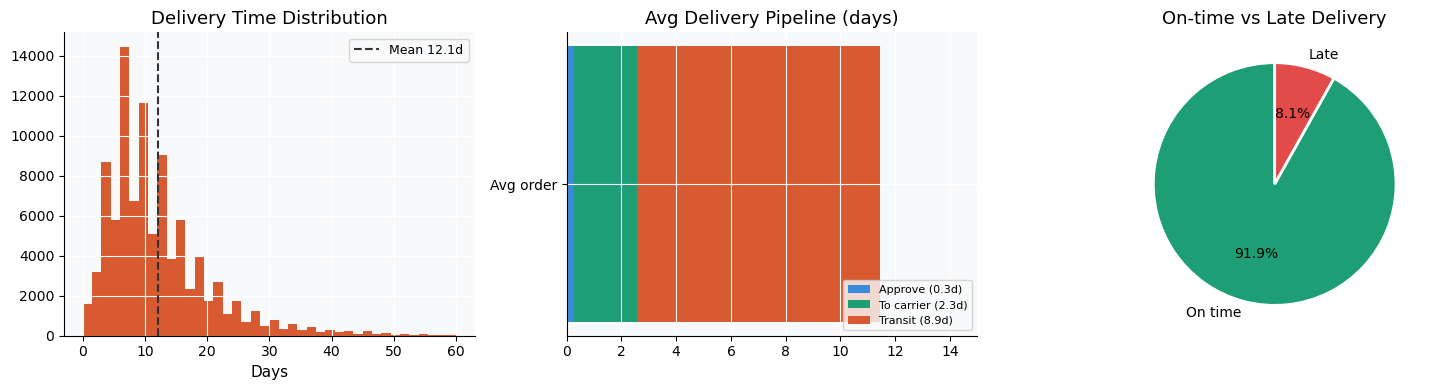

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Delivery time histogram
dt_clipped = deliv['days_to_deliver'][deliv['days_to_deliver'].between(0, 60)]
axes[0].hist(dt_clipped, bins=40, color='#D85A30', edgecolor='none')
axes[0].axvline(deliv['days_to_deliver'].mean(), color='#333', linestyle='--',
                linewidth=1.5, label=f"Mean {deliv['days_to_deliver'].mean():.1f}d")
axes[0].set_title('Delivery Time Distribution')
axes[0].set_xlabel('Days')
axes[0].legend(fontsize=9)

# Delivery stage breakdown (stacked)
stages = ['days_to_approve','days_to_carrier','days_in_transit']
stage_means = deliv[stages].mean()
colors_stage = ['#378ADD','#1D9E75','#D85A30']
axes[1].barh(['Avg order'], [stage_means['days_to_approve']], color=colors_stage[0],
             label=f"Approve ({stage_means['days_to_approve']:.1f}d)")
axes[1].barh(['Avg order'], [stage_means['days_to_carrier']],
             left=[stage_means['days_to_approve']], color=colors_stage[1],
             label=f"To carrier ({stage_means['days_to_carrier']:.1f}d)")
axes[1].barh(['Avg order'], [stage_means['days_in_transit']],
             left=[stage_means['days_to_approve'] + stage_means['days_to_carrier']],
             color=colors_stage[2],
             label=f"Transit ({stage_means['days_in_transit']:.1f}d)")
axes[1].set_title('Avg Delivery Pipeline (days)')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].set_xlim(0, 15)

# On-time vs late
on_time_counts = deliv['on_time'].value_counts()
labels = ['On time', 'Late']
axes[2].pie([on_time_counts.get(True,0), on_time_counts.get(False,0)],
            labels=labels, autopct='%1.1f%%', startangle=90,
            colors=['#1D9E75','#E24B4A'], wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title('On-time vs Late Delivery')

plt.tight_layout()
plt.show()

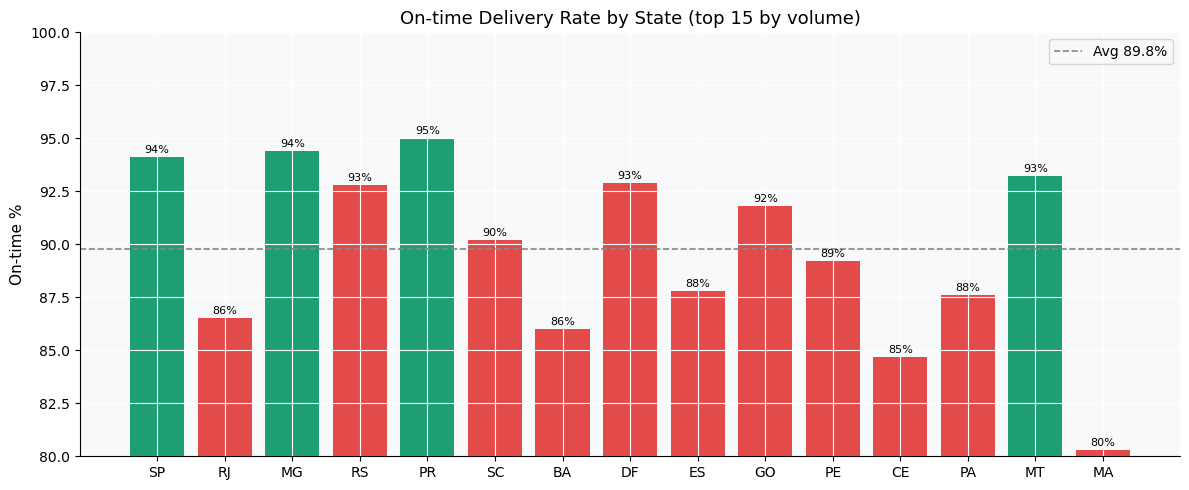

In [12]:
# On-time rate by state (top 15 states by volume)
deliv_state = deliv.merge(customers[['customer_id','customer_state']], on='customer_id')
state_perf = deliv_state.groupby('customer_state').agg(
    orders=('order_id','count'),
    on_time_rate=('on_time','mean'),
    avg_days=('days_to_deliver','mean')
).sort_values('orders', ascending=False).head(15)
state_perf['on_time_pct'] = (state_perf['on_time_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(state_perf.index, state_perf['on_time_pct'],
              color=['#1D9E75' if v >= 93 else '#E24B4A' for v in state_perf['on_time_pct']],
              edgecolor='none')
ax.axhline(state_perf['on_time_pct'].mean(), color='#888', linestyle='--',
           linewidth=1.2, label=f"Avg {state_perf['on_time_pct'].mean():.1f}%")
ax.set_ylim(80, 100)
ax.set_title('On-time Delivery Rate by State (top 15 by volume)')
ax.set_ylabel('On-time %')
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Customer Reviews <a id='6-reviews'></a>

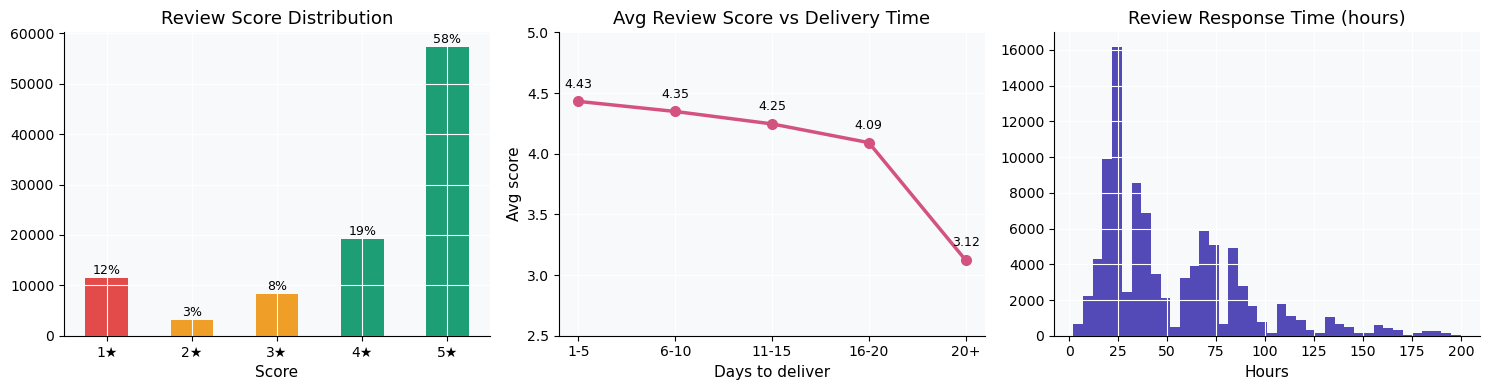

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Score distribution
score_counts = reviews['review_score'].value_counts().sort_index()
colors_score = ['#E24B4A','#EF9F27','#EF9F27','#1D9E75','#1D9E75']
score_counts.plot(kind='bar', ax=axes[0], color=colors_score, edgecolor='none')
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_xticklabels(['1★','2★','3★','4★','5★'], rotation=0)
for bar in axes[0].patches:
    pct = bar.get_height() / len(reviews) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)

# Review score vs delivery time
rev_deliv = reviews.merge(deliv[['order_id','days_to_deliver']], on='order_id')
rev_deliv['delivery_bin'] = pd.cut(rev_deliv['days_to_deliver'],
    bins=[0,5,10,15,20,100], labels=['1-5','6-10','11-15','16-20','20+'])
score_by_deliv = rev_deliv.groupby('delivery_bin')['review_score'].mean()
axes[1].plot(score_by_deliv.index, score_by_deliv.values,
             marker='o', linewidth=2.5, color='#D4537E', markersize=7)
axes[1].set_ylim(2.5, 5.0)
axes[1].set_title('Avg Review Score vs Delivery Time')
axes[1].set_xlabel('Days to deliver')
axes[1].set_ylabel('Avg score')
for x, y in zip(range(len(score_by_deliv)), score_by_deliv.values):
    axes[1].annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

# Response time distribution
reviews['response_hours'] = (
    reviews['review_answer_timestamp'] - reviews['review_creation_date']
).dt.total_seconds() / 3600
resp_clipped = reviews['response_hours'][reviews['response_hours'].between(0, 200)]
axes[2].hist(resp_clipped, bins=40, color='#534AB7', edgecolor='none')
axes[2].set_title('Review Response Time (hours)')
axes[2].set_xlabel('Hours')

plt.tight_layout()
plt.show()

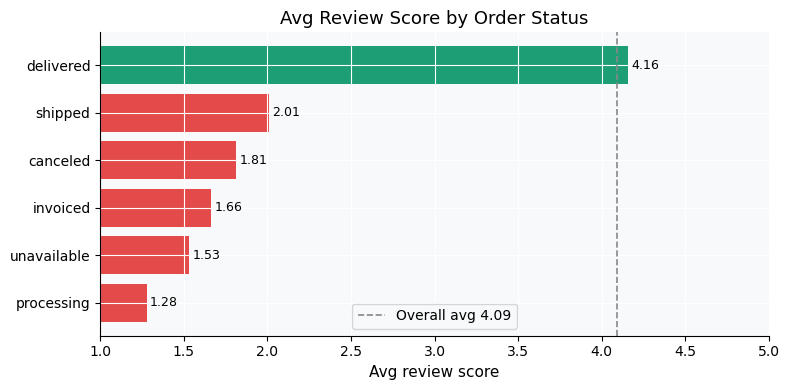

In [14]:
# Score by order status
rev_status = reviews.merge(orders[['order_id','order_status']], on='order_id')
score_by_status = rev_status.groupby('order_status')['review_score'].agg(['mean','count'])
score_by_status = score_by_status[score_by_status['count'] >= 50].sort_values('mean')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(score_by_status.index, score_by_status['mean'],
               color=['#E24B4A' if v < 3.5 else '#1D9E75' for v in score_by_status['mean']],
               edgecolor='none')
ax.set_xlim(1, 5)
ax.axvline(4.09, color='#888', linestyle='--', linewidth=1.2, label='Overall avg 4.09')
ax.set_title('Avg Review Score by Order Status')
ax.set_xlabel('Avg review score')
ax.legend()
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Product & Category Analysis <a id='7-products'></a>

In [15]:
# Merge products with translations
products_en = products.merge(cat_trans, on='product_category_name', how='left')
products_en['category'] = products_en['product_category_name_english'].fillna(
    products_en['product_category_name'])

# Order items enriched
items_rich = order_items.merge(products_en[['product_id','category']], on='product_id', how='left')
items_rich = items_rich.merge(orders[['order_id','order_purchase_timestamp']], on='order_id')

# Top 15 categories
cat_stats = items_rich.groupby('category').agg(
    orders=('order_id','nunique'),
    revenue=('price','sum'),
    avg_price=('price','mean'),
    items=('order_item_id','count')
).sort_values('orders', ascending=False).head(15)

print('Top 15 categories by orders:')
print(cat_stats.round(0).to_string())

Top 15 categories by orders:
                       orders    revenue  avg_price  items
category                                                  
bed_bath_table           9417  1036989.0       93.0  11115
health_beauty            8836  1258681.0      130.0   9670
sports_leisure           7720   988049.0      114.0   8641
computers_accessories    6689   911954.0      117.0   7827
furniture_decor          6449   729762.0       88.0   8334
housewares               5884   632249.0       91.0   6964
watches_gifts            5624  1205006.0      201.0   5991
telephony                4199   323668.0       71.0   4545
auto                     3897   592720.0      140.0   4235
toys                     3886   483947.0      118.0   4117
cool_stuff               3632   635291.0      167.0   3796
garden_tools             3518   485256.0      112.0   4347
perfumery                3162   399125.0      117.0   3419
baby                     2885   411765.0      134.0   3065
electronics              25

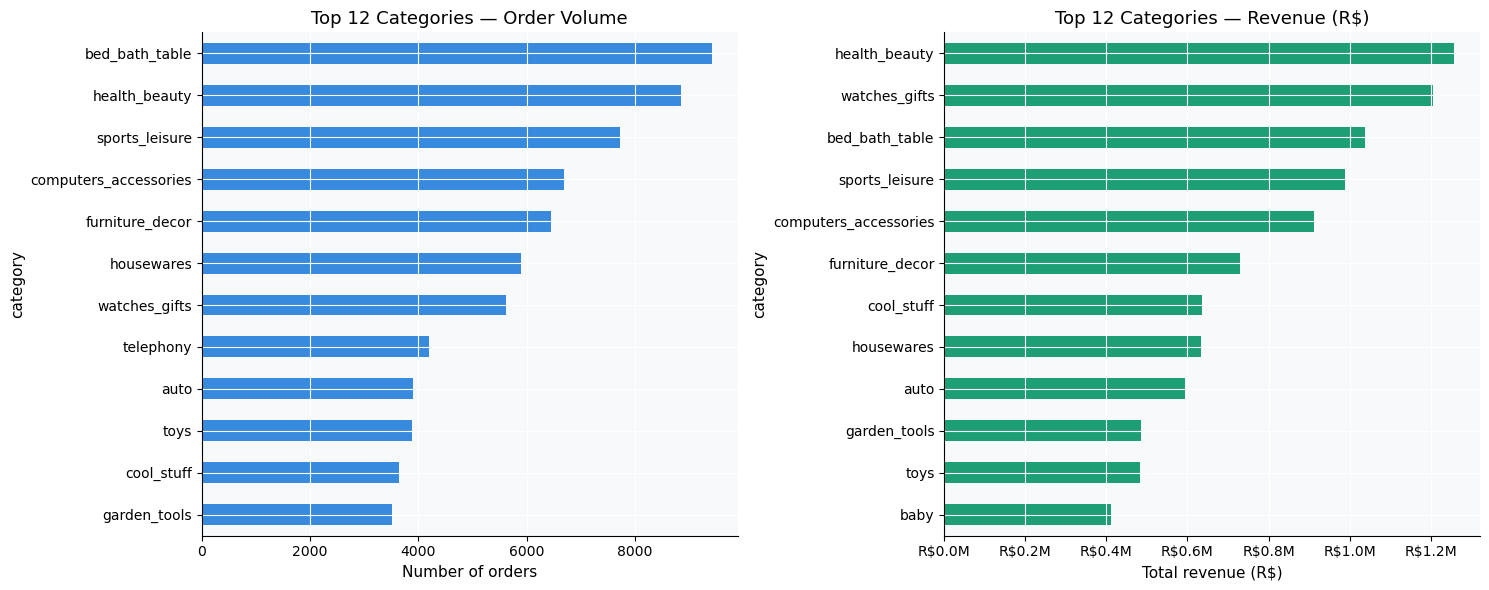

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 12 by orders
top12 = cat_stats.head(12)
top12['orders'].sort_values().plot(kind='barh', ax=axes[0], color='#378ADD', edgecolor='none')
axes[0].set_title('Top 12 Categories — Order Volume')
axes[0].set_xlabel('Number of orders')

# Top 12 by revenue
top12_rev = cat_stats.sort_values('revenue', ascending=False).head(12)
top12_rev['revenue'].sort_values().plot(kind='barh', ax=axes[1], color='#1D9E75', edgecolor='none')
axes[1].set_title('Top 12 Categories — Revenue (R$)')
axes[1].set_xlabel('Total revenue (R$)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

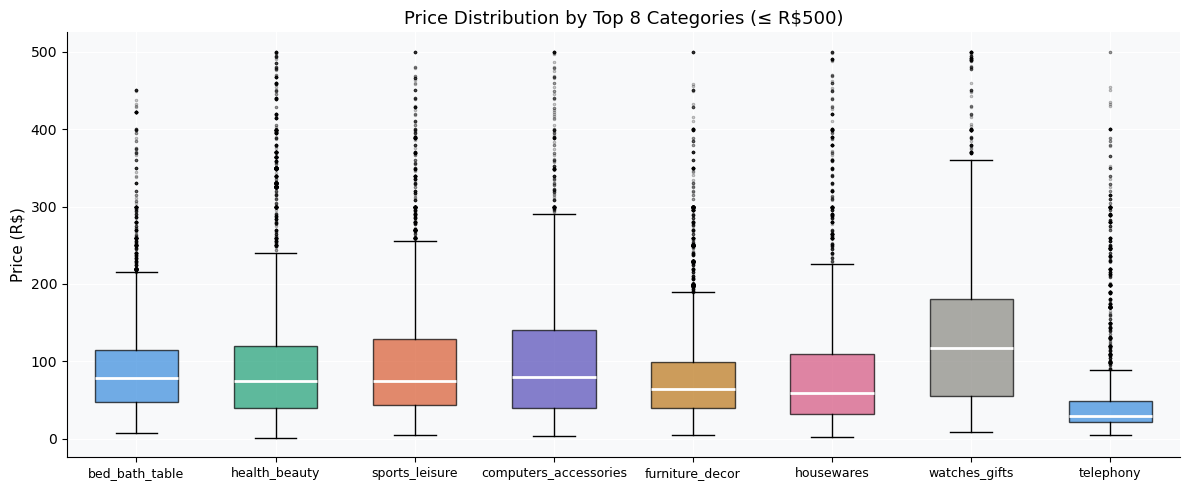

In [17]:
# Price distribution by top categories
top8_cats = cat_stats.head(8).index.tolist()
items_top8 = items_rich[items_rich['category'].isin(top8_cats)]
items_top8_clipped = items_top8[items_top8['price'] <= 500]

fig, ax = plt.subplots(figsize=(12, 5))
for i, cat in enumerate(top8_cats):
    data = items_top8_clipped[items_top8_clipped['category'] == cat]['price']
    ax.boxplot(data.values, positions=[i], widths=0.6,
               patch_artist=True,
               boxprops=dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.7),
               medianprops=dict(color='white', linewidth=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.3))

ax.set_xticks(range(len(top8_cats)))
ax.set_xticklabels([c.replace(' ', '\n') for c in top8_cats], fontsize=9)
ax.set_title('Price Distribution by Top 8 Categories (≤ R$500)')
ax.set_ylabel('Price (R$)')
plt.tight_layout()
plt.show()

## 8. Geographic Analysis <a id='8-geography'></a>

In [18]:
# Orders and revenue by customer state
orders_geo = orders.merge(customers[['customer_id','customer_state']], on='customer_id')
orders_geo = orders_geo.merge(
    payments.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left')

state_stats = orders_geo.groupby('customer_state').agg(
    orders=('order_id','count'),
    revenue=('payment_value','sum'),
    avg_order=('payment_value','mean')
).sort_values('orders', ascending=False)

print('Orders and revenue by state:')
print(state_stats.round(0).to_string())

Orders and revenue by state:
                orders    revenue  avg_order
customer_state                              
SP               41746  5998227.0      144.0
RJ               12852  2144380.0      167.0
MG               11635  1872257.0      161.0
RS                5466   890899.0      163.0
PR                5045   811156.0      161.0
SC                3637   623086.0      171.0
BA                3380   616646.0      182.0
DF                2140   355141.0      166.0
ES                2033   325968.0      160.0
GO                2020   350092.0      173.0
PE                1652   324850.0      197.0
CE                1336   279464.0      209.0
PA                 975   218296.0      224.0
MT                 907   187029.0      206.0
MA                 747   152523.0      204.0
MS                 715   137535.0      192.0
PB                 536   141546.0      264.0
PI                 495   108524.0      219.0
RN                 485   102718.0      212.0
AL                 413    

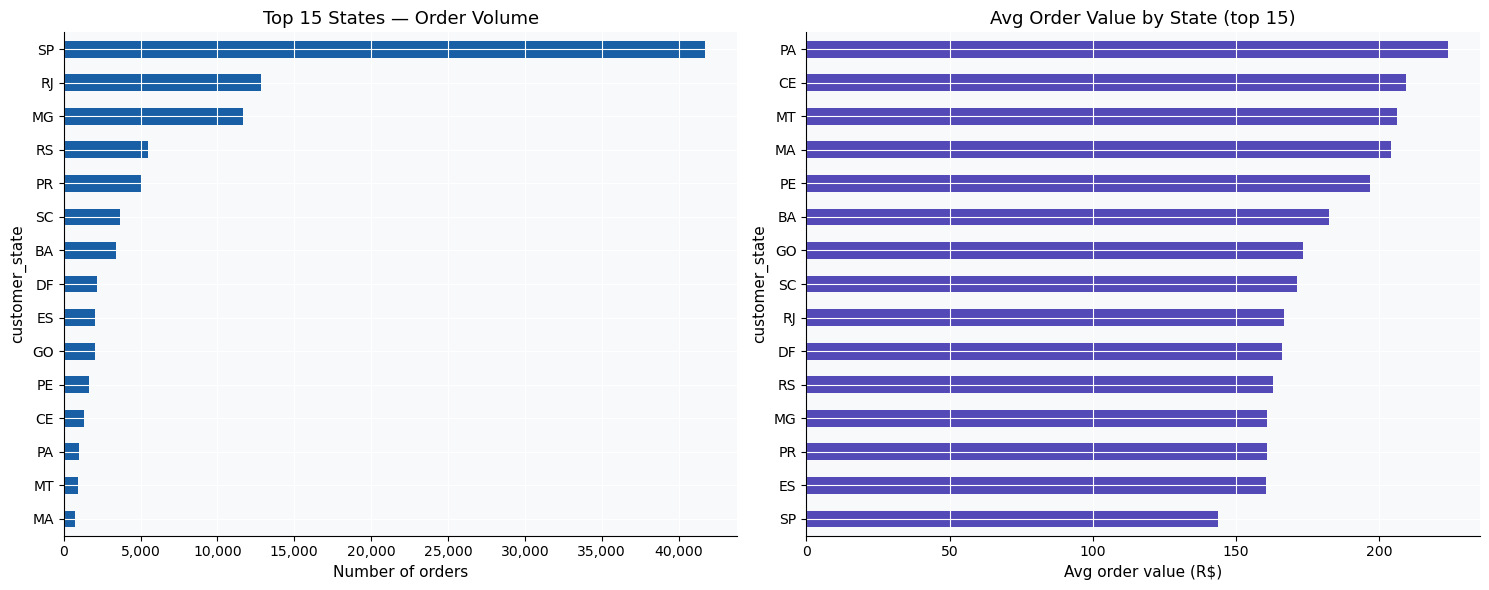

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Orders by state
top_states = state_stats.head(15)
top_states['orders'].sort_values().plot(kind='barh', ax=axes[0], color='#185FA5', edgecolor='none')
axes[0].set_title('Top 15 States — Order Volume')
axes[0].set_xlabel('Number of orders')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Avg order value by state
top_states['avg_order'].sort_values().plot(kind='barh', ax=axes[1], color='#534AB7', edgecolor='none')
axes[1].set_title('Avg Order Value by State (top 15)')
axes[1].set_xlabel('Avg order value (R$)')

plt.tight_layout()
plt.show()

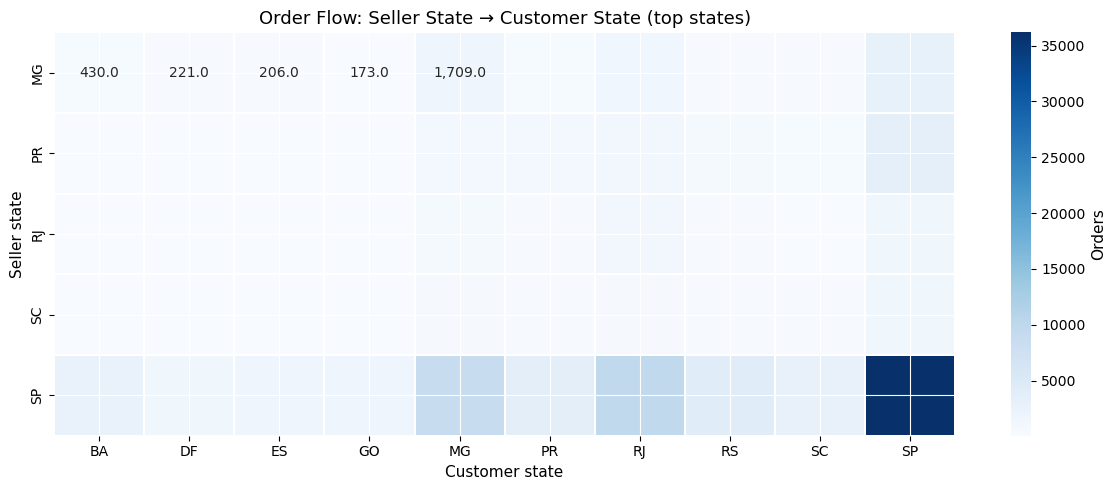

In [20]:
# Seller vs customer state flow (top 10 seller states)
flow = order_items.merge(orders[['order_id','customer_id']], on='order_id')
flow = flow.merge(customers[['customer_id','customer_state']], on='customer_id')
flow = flow.merge(sellers[['seller_id','seller_state']], on='seller_id')

cross = flow.groupby(['seller_state','customer_state']).size().reset_index(name='orders')
top_seller_states = flow['seller_state'].value_counts().head(5).index
cross_top = cross[cross['seller_state'].isin(top_seller_states)]

pivot = cross_top.pivot_table(index='seller_state', columns='customer_state',
                               values='orders', fill_value=0)
top_cust_states = flow['customer_state'].value_counts().head(10).index
pivot = pivot[pivot.columns.intersection(top_cust_states)]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=',', cmap='Blues', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Orders'})
ax.set_title('Order Flow: Seller State → Customer State (top states)')
ax.set_ylabel('Seller state')
ax.set_xlabel('Customer state')
plt.tight_layout()
plt.show()

## 9. Customer Behaviour <a id='9-customers'></a>

In [21]:
# Repeat purchase analysis
customer_orders = orders.merge(customers[['customer_id','customer_unique_id']], on='customer_id')
order_freq = customer_orders.groupby('customer_unique_id')['order_id'].count().value_counts().sort_index()

print('Order frequency distribution:')
for freq, count in order_freq.head(6).items():
    pct = count / order_freq.sum() * 100
    print(f'  {freq} order(s): {count:>8,} customers  ({pct:.1f}%)')

repeat_rate = (1 - order_freq.get(1, 0) / order_freq.sum()) * 100
print(f'\nRepeat purchase rate: {repeat_rate:.1f}%')

Order frequency distribution:
  1 order(s):   93,099 customers  (96.9%)
  2 order(s):    2,745 customers  (2.9%)
  3 order(s):      203 customers  (0.2%)
  4 order(s):       30 customers  (0.0%)
  5 order(s):        8 customers  (0.0%)
  6 order(s):        6 customers  (0.0%)

Repeat purchase rate: 3.1%


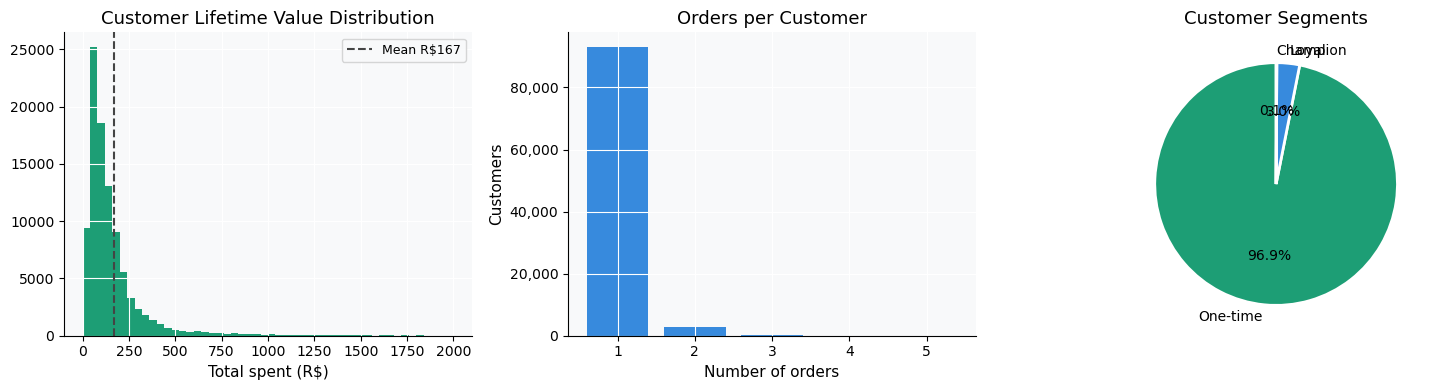

In [22]:
# Customer lifetime value segments
clv = customer_orders.merge(
    payments.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left'
)
clv_summary = clv.groupby('customer_unique_id').agg(
    total_orders=('order_id','count'),
    total_spent=('payment_value','sum'),
    first_order=('order_purchase_timestamp','min'),
    last_order=('order_purchase_timestamp','max')
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# CLV distribution
clv_clipped = clv_summary['total_spent'][clv_summary['total_spent'] <= 2000]
axes[0].hist(clv_clipped, bins=50, color='#1D9E75', edgecolor='none')
axes[0].set_title('Customer Lifetime Value Distribution')
axes[0].set_xlabel('Total spent (R$)')
axes[0].axvline(clv_summary['total_spent'].mean(), color='#444', linestyle='--',
                label=f"Mean R${clv_summary['total_spent'].mean():.0f}")
axes[0].legend(fontsize=9)

# Orders per customer
order_freq_plot = order_freq.head(5)
axes[1].bar(order_freq_plot.index.astype(str), order_freq_plot.values,
            color='#378ADD', edgecolor='none')
axes[1].set_title('Orders per Customer')
axes[1].set_xlabel('Number of orders')
axes[1].set_ylabel('Customers')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Spend by segment
def rfm_segment(row):
    if row['total_orders'] >= 3 and row['total_spent'] >= 500: return 'Champion'
    elif row['total_orders'] >= 2: return 'Loyal'
    else: return 'One-time'
clv_summary['segment'] = clv_summary.apply(rfm_segment, axis=1)
seg_counts = clv_summary['segment'].value_counts()
axes[2].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=['#1D9E75','#378ADD','#888780'],
            wedgeprops={'edgecolor':'white','linewidth':2}, startangle=90)
axes[2].set_title('Customer Segments')

plt.tight_layout()
plt.show()

## 10. Seller Analysis <a id='10-sellers'></a>

In [23]:
seller_stats = order_items.merge(
    orders[['order_id','order_purchase_timestamp']], on='order_id'
).groupby('seller_id').agg(
    orders=('order_id','nunique'),
    items=('order_item_id','count'),
    revenue=('price','sum'),
    avg_price=('price','mean')
).sort_values('revenue', ascending=False)

# Seller review scores
seller_rev = order_items.merge(reviews[['order_id','review_score']], on='order_id', how='left')
seller_scores = seller_rev.groupby('seller_id')['review_score'].mean()
seller_stats['avg_score'] = seller_stats.index.map(seller_scores)

print('Seller stats summary:')
print(seller_stats.describe().round(1).to_string())

Seller stats summary:
       orders   items   revenue  avg_price  avg_score
count  3095.0  3095.0    3095.0     3095.0     3090.0
mean     32.3    36.4    4391.5      176.3        4.0
std     105.1   119.2   13922.0      322.1        1.0
min       1.0     1.0       3.5        3.5        1.0
25%       2.0     2.0     208.8       52.2        3.7
50%       6.0     8.0     821.5       95.5        4.2
75%      21.5    24.0    3280.8      174.0        4.6
max    1854.0  2033.0  229472.6     6729.0        5.0


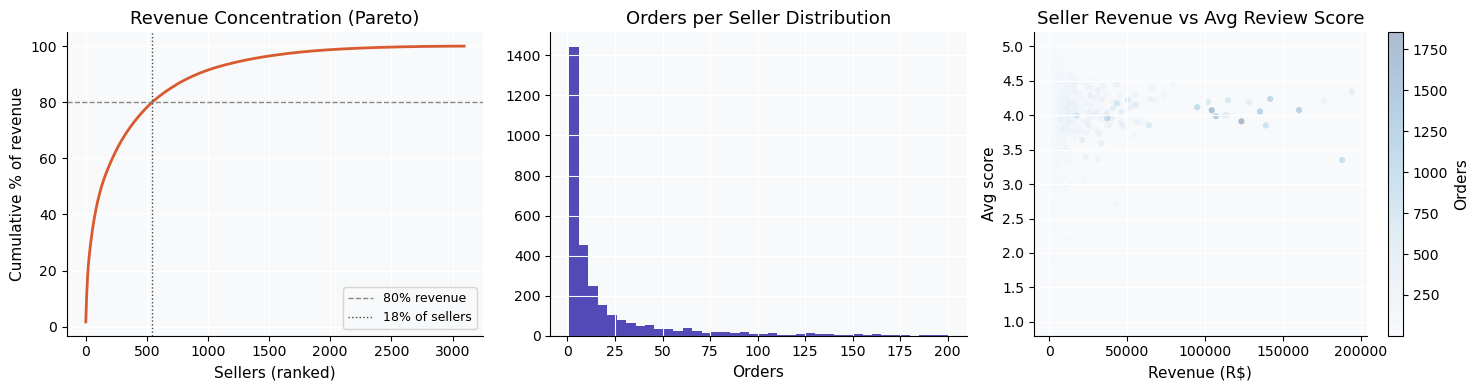

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Revenue concentration (Pareto)
seller_sorted = seller_stats['revenue'].sort_values(ascending=False)
cumulative_pct = seller_sorted.cumsum() / seller_sorted.sum() * 100
axes[0].plot(range(1, len(cumulative_pct)+1), cumulative_pct.values,
             color='#D85A30', linewidth=2)
axes[0].axhline(80, color='#888', linestyle='--', linewidth=1, label='80% revenue')
idx_80 = (cumulative_pct >= 80).idxmax()
pct_sellers_80 = seller_stats.index.get_loc(idx_80) / len(seller_stats) * 100
axes[0].axvline(seller_stats.index.get_loc(idx_80), color='#444', linestyle=':',
                linewidth=1, label=f'{pct_sellers_80:.0f}% of sellers')
axes[0].set_title('Revenue Concentration (Pareto)')
axes[0].set_xlabel('Sellers (ranked)')
axes[0].set_ylabel('Cumulative % of revenue')
axes[0].legend(fontsize=9)

# Orders per seller distribution
orders_per_seller = seller_stats['orders'][seller_stats['orders'] <= 200]
axes[1].hist(orders_per_seller, bins=40, color='#534AB7', edgecolor='none')
axes[1].set_title('Orders per Seller Distribution')
axes[1].set_xlabel('Orders')

# Seller revenue vs avg score
scatter_data = seller_stats.dropna(subset=['avg_score'])
scatter_data = scatter_data[scatter_data['revenue'] <= 200000]
sc = axes[2].scatter(scatter_data['revenue'], scatter_data['avg_score'],
                     alpha=0.3, s=20, c=scatter_data['orders'],
                     cmap='Blues', edgecolors='none')
plt.colorbar(sc, ax=axes[2], label='Orders')
axes[2].set_title('Seller Revenue vs Avg Review Score')
axes[2].set_xlabel('Revenue (R$)')
axes[2].set_ylabel('Avg score')

plt.tight_layout()
plt.show()

## 11. Key Insights Summary <a id='11-insights'></a>

### 📦 Orders
- **~10x growth** in 2 years (Sep 2016 → Aug 2018)
- **Black Friday 2017** is the clear peak (~7,500 orders in Nov 2017)
- Most orders placed on **Monday–Wednesday**, fewest on Sunday
- Peak order hour is **10am–2pm**

### 💳 Revenue & Payments
- **73.9% of orders** use credit card; boleto is 19%
- Avg order value is **~R$160** but median is lower (~R$100) — right-skewed distribution
- Many customers use **installments** (parcelas), often 1–3x

### 🚚 Delivery
- Average delivery is **12.5 days** from purchase
- **~92% of orders** are delivered on time
- Pipeline: Approve (0.5d) → Carrier (3d) → Transit (9d)
- Northern states (AM, RR, PA) have **worst on-time rates** due to distance from São Paulo sellers

### ⭐ Reviews
- Bimodal distribution: **57% score 5★**, but 11% score 1★
- **Strong correlation** between late delivery and low scores (4.4★ fast → 3.3★ slow)
- Canceled orders average **2.1★** vs delivered orders at **4.2★**

### 🛍️ Products & Categories
- **bed_bath_table** leads by order volume; **computers_accessories** leads by revenue
- Rank divergence between volume and revenue reveals **high-ticket vs high-frequency** categories

### 🗺️ Geography
- **São Paulo state = 42% of all orders** — extreme concentration
- Most sellers are also in SP → long-distance shipments to northern/northeastern states

### 👤 Customers
- **96.6% of customers purchased only once** — retention is the key growth lever
- CLV is mostly under R$200 for one-time buyers

### 🏪 Sellers
- **Top 20% of sellers generate ~80% of revenue** (Pareto principle holds)
- High-revenue sellers tend to have **slightly higher review scores**

---
*Next steps: load transformed data into BigQuery using `dbt run`, then connect to Looker Studio or similar BI tool for live dashboards.*